# Monte Carlo Kernel Benchmarking

This notebook performs a comprehensive performance evaluation of different OpenCL kernels implemented for the Monte Carlo simulation. We compare the **Standard 1D**, **Ping-Pong**, **2D Grid-Stride**, **2D Ping-Pong**, and **2D Two-Barriers** approaches across various metrics, including execution time, memory bandwidth, VRAM footprint, and throughput.

**Bandwidth metric.** The reported *Effective Bandwidth* is computed as `(n_runs × n_cells × 4 + n_wg × 4) / time` (canonical effective-bandwidth convention: every global-memory load/store instruction is counted at face value, regardless of cache hits). Because `p_vec` (~600 KB for this habitat) fits in the GPU's L2 cache, the measured values can exceed the device's DRAM peak (the 4050 is ~190-270 GB/s) — in that regime the metric reflects cache→SM throughput, not VRAM→SM.

## Environment Setup

Loading environment variables and importing necessary modules for the simulation and data analysis.

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from dotenv import load_dotenv

from pyroclast import (
    FileMapRepository,
    HabitatCriteria,
    PyOpenCLAdapter,
    PyOpenCLMonteCarloAdapter,
    PyOpenCLMonteCarloPingPongAdapter,
    PyOpenCLMonteCarlo2DAdapter,
    PyOpenCLMonteCarlo2DPingPongAdapter,
    PyOpenCLMonteCarlo2DTwoBarriersAdapter,
)
from pyroclast.domain.models import MonteCarloConfig
from pyroclast.services import run_preprocessing_batch

load_dotenv()
data_path = os.getenv("DATA_PATH", "data").strip('"\'')
cache_dir = Path(os.getenv("CACHE_DIR", str(Path(data_path) / "cache")).strip('"\''))

## Data Preparation

Running the preprocessing pipeline to obtain the compacted habitat data required for the Monte Carlo simulation.

In [2]:
repo = FileMapRepository(data_path)
preprocess_adapter = PyOpenCLAdapter()
compacted = run_preprocessing_batch(
    repo=repo,
    compute=preprocess_adapter,
    criteria=HabitatCriteria(),
    cache_dir=cache_dir,
)
target_habitat = compacted[0]
print(f"Selected Habitat: {target_habitat.habitat_code} ({target_habitat.n_cells} cells)")

Selected Habitat: 4090 (153989 cells)


pci id for fd 84: 10de:28e1, driver (null)
pci id for fd 85: 10de:28e1, driver (null)


## Phase 1: Single-Shot Performance Analysis

Executing a single benchmark run with a high number of simulations (1,000,000) for all kernels to collect detailed performance metrics including VRAM footprint and speedup.

In [ ]:
MC_RUNS = 1_000_000
THRESHOLD = 0.005
SEED = 42
N_BATCHES = 10

kernels_to_bench = [
    {"name": "Standard",       "adapter": PyOpenCLMonteCarloAdapter(profiling=True)},
    {"name": "Ping-Pong",      "adapter": PyOpenCLMonteCarloPingPongAdapter(profiling=True)},
    {"name": "2D-Stride",      "adapter": PyOpenCLMonteCarlo2DAdapter(profiling=True)},
    {"name": "2D-PingPong",    "adapter": PyOpenCLMonteCarlo2DPingPongAdapter(profiling=True)},
    {"name": "2D-TwoBarriers", "adapter": PyOpenCLMonteCarlo2DTwoBarriersAdapter(profiling=True)},
]

config = MonteCarloConfig(n_runs=MC_RUNS, threshold=THRESHOLD, seed=SEED)
phase1_data = []

print(f"Running Phase 1 Benchmark (R={MC_RUNS:,}, Batches={N_BATCHES})...")
for k in kernels_to_bench:
    adapter = k["adapter"]
    adapter.reset_profile()
    adapter.run(target_habitat, config)
    bench = adapter.benchmark()[0]

    total_time_ms = bench.mean_ms * N_BATCHES
    throughput = MC_RUNS / (total_time_ms / 1000.0)

    phase1_data.append({
        "Kernel": k["name"],
        "Time (ms)": total_time_ms,
        "Bandwidth (GB/s)": bench.bandwidth_gbs,
        "VRAM (MB)": bench.memory_mb,
        "Throughput (Sim/s)": throughput
    })

df_phase1 = pd.DataFrame(phase1_data)
std_time = df_phase1[df_phase1["Kernel"] == "Standard"]["Time (ms)"].values[0]
df_phase1["Speedup"] = std_time / df_phase1["Time (ms)"]

print("\nPhase 1 Results:")
display(df_phase1.style.format({
    "Time (ms)": "{:.2f}",
    "Bandwidth (GB/s)": "{:.1f}",
    "VRAM (MB)": "{:.2f}",
    "Throughput (Sim/s)": "{:.0f}",
    "Speedup": "{:.2f}x"
}))

## Phase 2: Scaling and Throughput Analysis

Performing a parametric sweep from 1,000,000 to 2,000,000 simulations (with 100,000 increments) to observe the scalability of each kernel and how metrics like effective bandwidth and throughput behave under increasing load.

In [ ]:
RUNS_MIN = 1_000_000
RUNS_MAX = 2_000_000
INCREMENT = 100_000
N_BATCHES_SCALING = 1

run_sizes = list(range(RUNS_MIN, RUNS_MAX + 1, INCREMENT))
results_scaling = {k["name"]: [] for k in kernels_to_bench}
bandwidths_scaling = {k["name"]: [] for k in kernels_to_bench}
throughputs_scaling = {k["name"]: [] for k in kernels_to_bench}

print("Running Phase 2 Scaling Benchmark...")
for runs in run_sizes:
    config = MonteCarloConfig(n_runs=runs, threshold=THRESHOLD, seed=SEED)
    for k in kernels_to_bench:
        adapter = k["adapter"]
        adapter.reset_profile()
        adapter.run_batched(target_habitat, config, N_BATCHES_SCALING)
        bench = adapter.benchmark()[0]
        
        total_time_ms = bench.mean_ms * N_BATCHES_SCALING
        throughput = runs / (total_time_ms / 1000.0)
        
        results_scaling[k["name"]].append(total_time_ms)
        bandwidths_scaling[k["name"]].append(bench.bandwidth_gbs)
        throughputs_scaling[k["name"]].append(throughput)
    print(f"  Completed R={runs:,}", end="\r")
print("\nScaling benchmark completed.")

## Visualization of Results

Plotting the scaling results to compare absolute execution times, standardized deviations, effective memory bandwidth, and computational throughput.

In [ ]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(2, 2, figsize=(16, 12))
colors = {
    "Standard": "#d62728",
    "Ping-Pong": "#ff7f0e",
    "2D-Stride": "#1f77b4",
    "2D-PingPong": "#2ca02c",
    "2D-TwoBarriers": "#9467bd"
}
markers = {
    "Standard": "v",
    "Ping-Pong": "s",
    "2D-Stride": "o",
    "2D-PingPong": "D",
    "2D-TwoBarriers": "P"
}

# Subplot 1: Time Scaling
for k in kernels_to_bench:
    name = k["name"]
    ax1.plot(run_sizes, results_scaling[name], marker=markers[name], label=name, color=colors[name])
ax1.set_xlabel("Number of Simulations (MC_RUNS)")
ax1.set_ylabel("Execution Time (ms)")
ax1.set_title("Execution Time Scaling")
ax1.grid(True, linestyle="--", alpha=0.6)
ax1.legend()

# Subplot 2: Standardized Relative Time (Deviation from Mean)
for k in kernels_to_bench:
    name = k["name"]
    # Standardized Relative Performance calculation
    deviations = []
    for i, runs in enumerate(run_sizes):
        group_mean = np.mean([results_scaling[other["name"]][i] for other in kernels_to_bench])
        val = results_scaling[name][i]
        dev_pct = (val / group_mean - 1.0) * 100.0
        deviations.append(dev_pct)
    ax2.plot(run_sizes, deviations, marker=markers[name], label=name, color=colors[name])
ax2.axhline(0.0, color='black', linestyle='-', alpha=0.8, label='Group Mean')
ax2.set_xlabel("Number of Simulations (MC_RUNS)")
ax2.set_ylabel("Deviation from Mean (%)")
ax2.set_title("Relative Performance (Standardized Time)")
ax2.grid(True, linestyle="--", alpha=0.6)
ax2.legend()

# Subplot 3: Bandwidth scaling
for k in kernels_to_bench:
    name = k["name"]
    ax3.plot(run_sizes, bandwidths_scaling[name], marker=markers[name], label=name, color=colors[name])
ax3.set_xlabel("Number of Simulations (MC_RUNS)")
ax3.set_ylabel("Effective Bandwidth (GB/s)")
ax3.set_title("Memory Bandwidth Efficiency")
ax3.grid(True, linestyle="--", alpha=0.6)
ax3.legend()

# Subplot 4: Throughput
for k in kernels_to_bench:
    name = k["name"]
    ax4.plot(run_sizes, throughputs_scaling[name], marker=markers[name], label=name, color=colors[name])
ax4.set_xlabel("Number of Simulations (MC_RUNS)")
ax4.set_ylabel("Throughput (Simulations/s)")
ax4.set_title("Computational Throughput")
ax4.grid(True, linestyle="--", alpha=0.6)
ax4.legend()

plt.suptitle(f"MC Kernel Comparative Analysis (Habitat: {target_habitat.habitat_code})", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Phase 3: Decoupled LWS and GWS Parameter Tuning Analysis

Following our optimizations to parameterize work-group sizes dynamically, the GPU parameter tuning sweep was executed using the standalone Python script `benchmark/benchmark_lws_gws.py`. The execution, profiling, and hardware telemetry have been decoupled from this notebook. The results were exported into the structured data file `benchmark/lws_gws_benchmark.csv`.

We now load the benchmark CSV data and plot the **Computational Throughput** and **Relative Performance (Deviation from Group Mean %)** to analyze work-group scaling behavior.

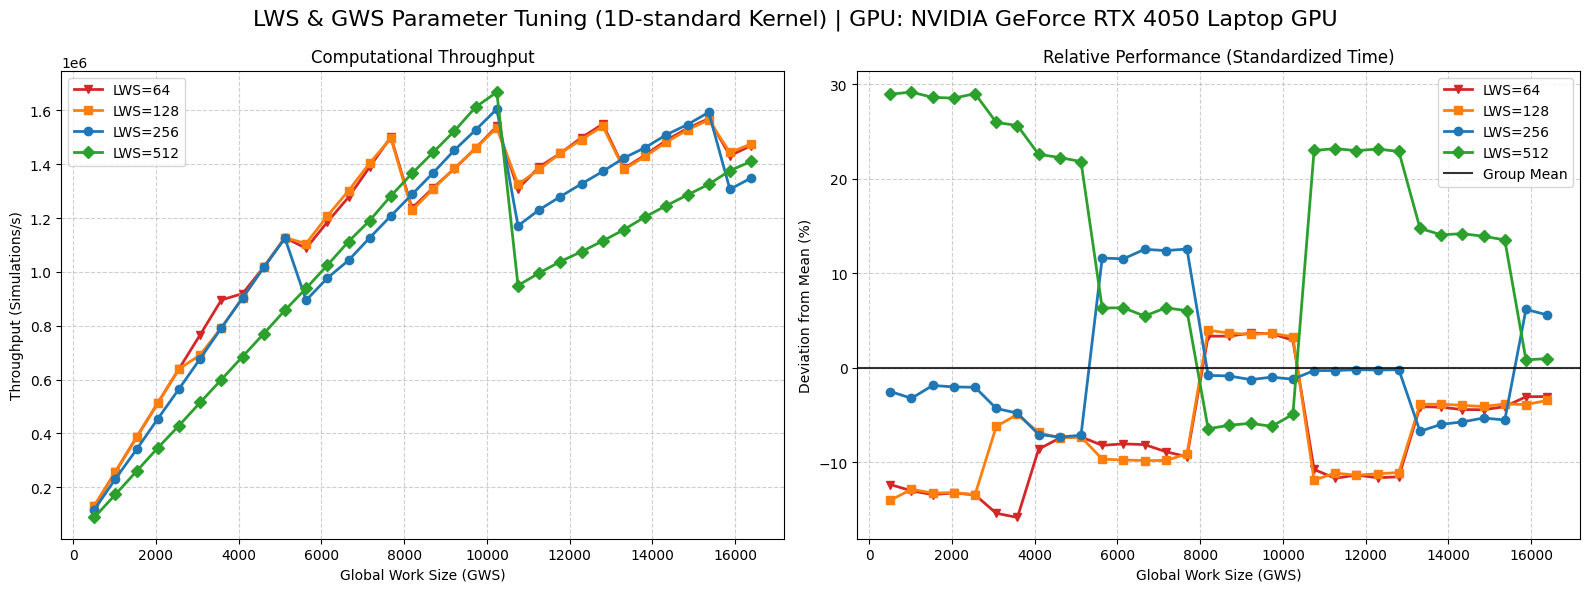

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load the benchmark CSV generated by benchmark_lws_gws.py
csv_path = Path("lws_gws_benchmark.csv")
if not csv_path.exists():
    raise FileNotFoundError(f"Benchmark data not found at '{csv_path}'. Please run the python sweep script first!")

df_bench = pd.read_csv(csv_path)
gpu_name = df_bench["GPU"].iloc[0] if "GPU" in df_bench.columns else "Unknown GPU"
kernel_label = df_bench["Kernel"].iloc[0] if "Kernel" in df_bench.columns else "Standard"

lws_options = sorted(df_bench["LWS"].unique())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colors_lws = {
    64:  "#d62728",
    128: "#ff7f0e",
    256: "#1f77b4",
    512: "#2ca02c"
}
markers_lws = {
    64:  "v",
    128: "s",
    256: "o",
    512: "D"
}

for lws in lws_options:
    sub_df = df_bench[df_bench["LWS"] == lws].sort_values("GWS")
    
    # Plot Throughput
    ax1.plot(
        sub_df["GWS"],
        sub_df["Throughput (Sim/s)"],
        marker=markers_lws[lws],
        label=f"LWS={lws}",
        color=colors_lws[lws],
        linewidth=2
    )
    
    # Plot Standardized Relative Time (Deviation from Mean %)
    ax2.plot(
        sub_df["GWS"],
        sub_df["Deviation from Mean (%)"],
        marker=markers_lws[lws],
        label=f"LWS={lws}",
        color=colors_lws[lws],
        linewidth=2
    )

# Subplot 1: Throughput
ax1.set_xlabel("Global Work Size (GWS)")
ax1.set_ylabel("Throughput (Simulations/s)")
ax1.set_title("Computational Throughput")
ax1.grid(True, linestyle="--", alpha=0.6)
ax1.legend()

# Subplot 2: Standardized Relative Performance
ax2.axhline(0.0, color='black', linestyle='-', alpha=0.8, label='Group Mean')
ax2.set_xlabel("Global Work Size (GWS)")
ax2.set_ylabel("Deviation from Mean (%)")
ax2.set_title("Relative Performance (Standardized Time)")
ax2.grid(True, linestyle="--", alpha=0.6)
ax2.legend()

plt.suptitle(f"LWS & GWS Parameter Tuning ({kernel_label} Kernel) | GPU: {gpu_name}", fontsize=16)
plt.tight_layout()
plt.show()